IMPORT PREPROCESSED DATASET

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/cleaned_dataset.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,OptionalServices,HighFriction,LoyalMonthlyPayer,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0,1,0.115423,0,1,0,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.472222,1,0,0.385075,0,2,0,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,0.027778,1,1,0.354229,1,2,0,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.625000,0,0,0.239303,0,3,0,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,0.027778,1,1,0.521891,1,0,1,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


SPLITTING DATA

In [36]:
from sklearn.model_selection import train_test_split

# Separating the features and target variable
x = df.drop(columns=['Churn'])
y = df['Churn']
print(y.value_counts(normalize=True))

# Splitting the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


INITIALIZING AND TRAINING MODELS

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initializing the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Training the models
print("Training the models...")
for name, model in models.items():
    model.fit(x_train, y_train)
    print(f"{name} trained.")

Training the models...
Logistic Regression trained.
Decision Tree trained.
Random Forest trained.


COMPARING MODELS

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_data = []

for name, model in models.items():
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    comparison_data.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

df_comparison = pd.DataFrame(comparison_data)

df_comparison.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.797019,0.640127,0.537433,0.584302
1,Random Forest,0.782825,0.617241,0.478610,0.539157
2,Decision Tree,0.716111,0.465054,0.462567,0.463807


EVALUATING MODELS

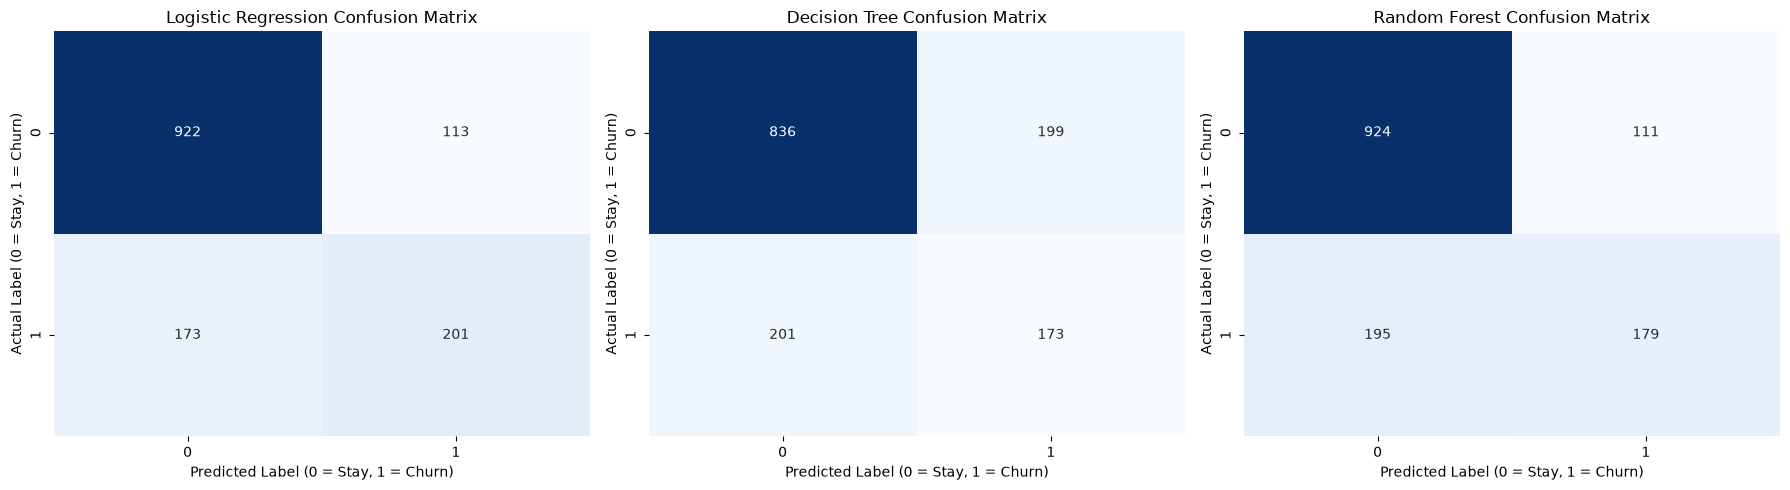

In [7]:
# CONFUSION MATRICES
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(x_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel('Predicted Label (0 = Stay, 1 = Churn)')
    ax.set_ylabel('Actual Label (0 = Stay, 1 = Churn)')

plt.tight_layout()
plt.show()

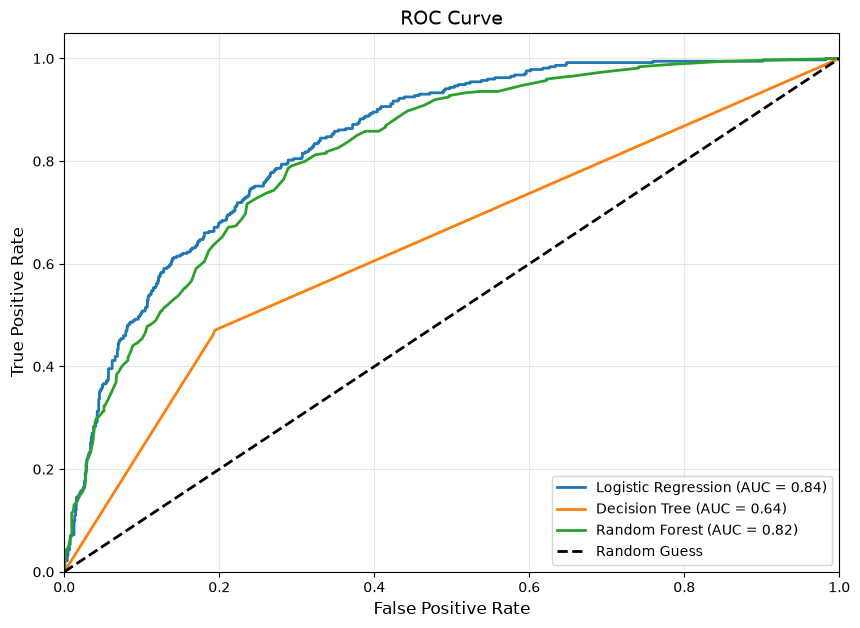

In [9]:
# ROC curves

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, model in models.items():
    y_probs = model.predict_proba(x_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

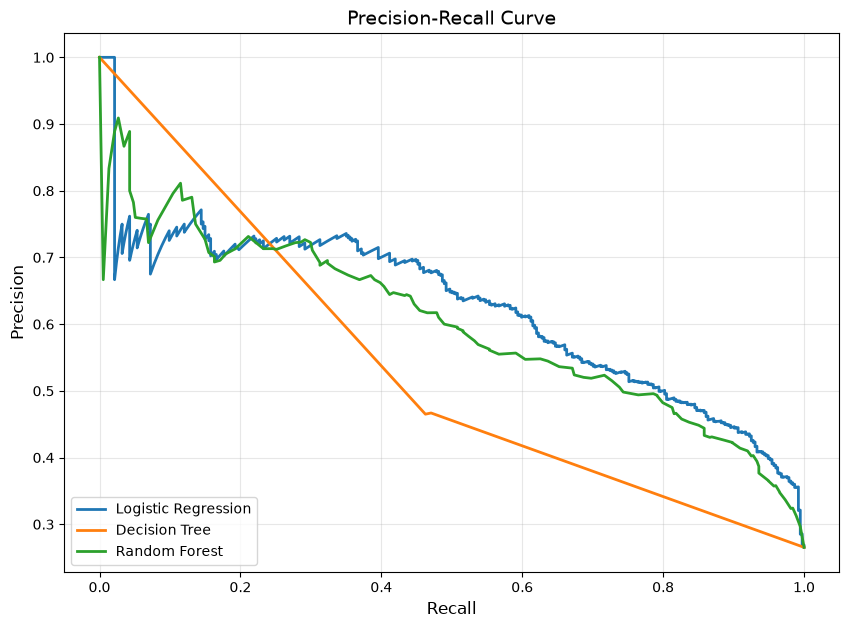

In [10]:
# precision-recall curves

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 7))

for name, model in models.items():
    y_probs = model.predict_proba(x_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    plt.plot(recall, precision, lw=2, label=name)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

FEATURE IMPORTANCE ANALYSIS

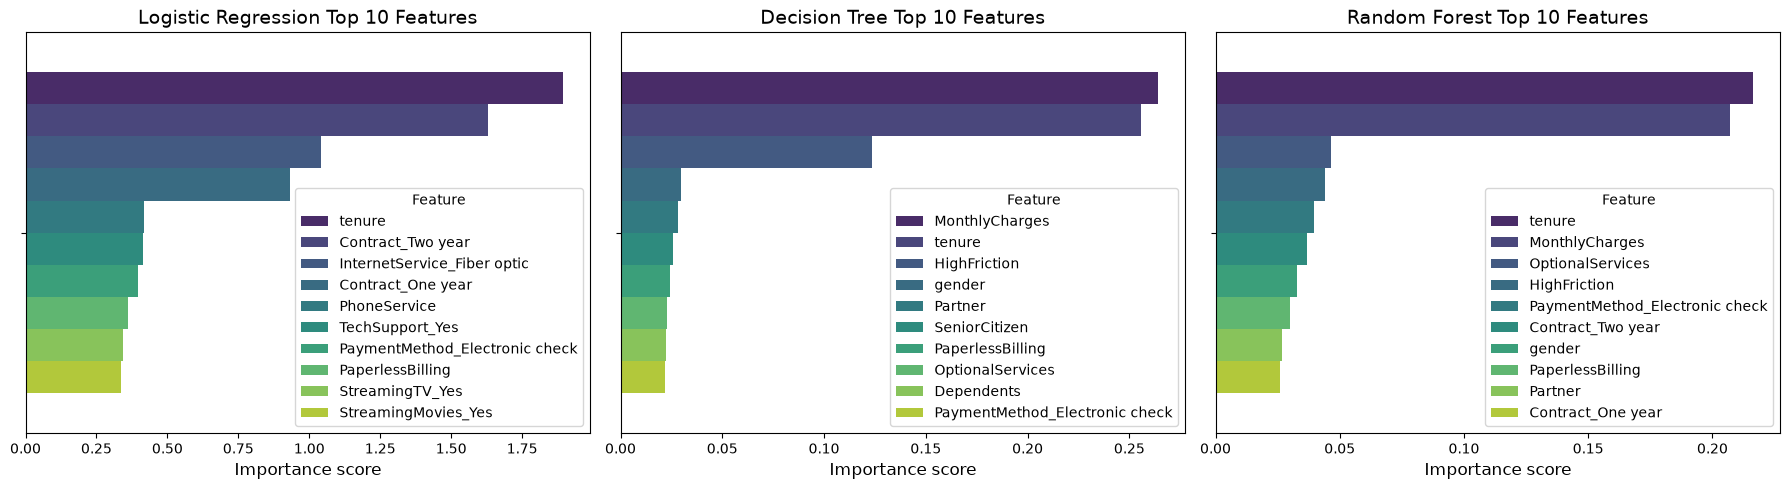

In [22]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = x_train.columns

for ax, (name, model) in zip(axes, models.items()):

    if name == "Logistic Regression":
        importances = np.abs(model.coef_[0])
    else:
        importances = model.feature_importances_

    importnace_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    top_10_features = importnace_df.sort_values(by='Importance', ascending=False).head(10)

    sns.barplot(x='Importance', hue='Feature', data=top_10_features, ax=ax, palette='viridis')

    ax.set_title(f"{name} Top 10 Features", fontsize=14)
    ax.set_xlabel('Importance score', fontsize=12)

plt.tight_layout()
plt.show()

ADVANCED REQUIREMENTS

In [24]:
# Show one case of overfitting

overfit_tree = DecisionTreeClassifier(random_state=42, max_depth=None)
overfit_tree.fit(x_train, y_train)

train_accuracy = accuracy_score(y_train, overfit_tree.predict(x_train))
test_accuracy = accuracy_score(y_test, overfit_tree.predict(x_test))

print(f"Overfit Decision Tree - Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

Overfit Decision Tree - Train Accuracy: 0.9979, Test Accuracy: 0.7161


In [33]:
# Regularization

# Regularizing the Decision Tree by limiting its depth (Pruning)
reg_tree_model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=20)
reg_tree_model.fit(x_train, y_train)
print(f"Regularized Tree Test Accuracy:       {accuracy_score(y_test, reg_tree_model.predict(x_test)):.4f}")

# Regularizing the Random Forest by limiting its depth
reg_rf_model = RandomForestClassifier(random_state=42, max_depth=5, min_samples_split=20)
reg_rf_model.fit(x_train, y_train)
print(f"Regularized Random Forest Test Accuracy: {accuracy_score(y_test, reg_rf_model.predict(x_test)):.4f}")

# Regularizing the Logistic Regression (L2 Penalty)
reg_log_reg_model = LogisticRegression(random_state=42, l1_ratio=0, C=1.0, max_iter=1000)
reg_log_reg_model.fit(x_train, y_train)
print(f"Regularized Logistic Regression Test Accuracy: {accuracy_score(y_test, reg_log_reg_model.predict(x_test)):.4f}")

Regularized Tree Test Accuracy:       0.7857
Regularized Random Forest Test Accuracy: 0.7913
Regularized Logistic Regression Test Accuracy: 0.7970


In [39]:
# Improving the model by hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Tuning Logistic Regression
log_params = {'C': [0.01, 0.1, 1, 10, 100]}
log_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), log_params, cv=5, scoring='f1')
log_grid.fit(x_train, y_train)
print(f"Best Logistic Params: {log_grid.best_params_}\n")

best_log = log_grid.best_estimator_
log_test_f1 = f1_score(y_test, best_log.predict(x_test))
print(f"Best Logistic Regression F1-score (Train): {log_grid.best_score_:.4f}")
print(f"Best Logistic Regression F1-score (Test): {log_test_f1:.4f}\n")

# Tuning Decision Tree
tree_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 10, 20]}
tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), tree_params, cv=5, scoring='f1')
tree_grid.fit(x_train, y_train)
print(f"Best Tree Params: {tree_grid.best_params_}\n")

best_tree = tree_grid.best_estimator_
tree_test_f1 = f1_score(y_test, best_tree.predict(x_test))
print(f"Best Decision Tree F1-score (Train): {tree_grid.best_score_:.4f}")
print(f"Best Decision Tree F1-score (Test): {tree_test_f1:.4f}\n")

# Tuning Random Forest
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1')
rf_grid.fit(x_train, y_train)
print(f"Best Forest Params: {rf_grid.best_params_}\n")

best_rf = rf_grid.best_estimator_
rf_test_f1 = f1_score(y_test, best_rf.predict(x_test))
print(f"Best Random Forest F1-score (Train): {rf_grid.best_score_:.4f}")
print(f"Best Random Forest F1-score (Test): {rf_test_f1:.4f}")

Best Logistic Params: {'C': 100}

Best Logistic Regression F1-score (Train): 0.5933
Best Logistic Regression F1-score (Test): 0.5785

Best Tree Params: {'max_depth': 10, 'min_samples_split': 20}

Best Decision Tree F1-score (Train): 0.5360
Best Decision Tree F1-score (Test): 0.5635

Best Forest Params: {'max_depth': 10, 'n_estimators': 200}

Best Random Forest F1-score (Train): 0.5751
Best Random Forest F1-score (Test): 0.5805


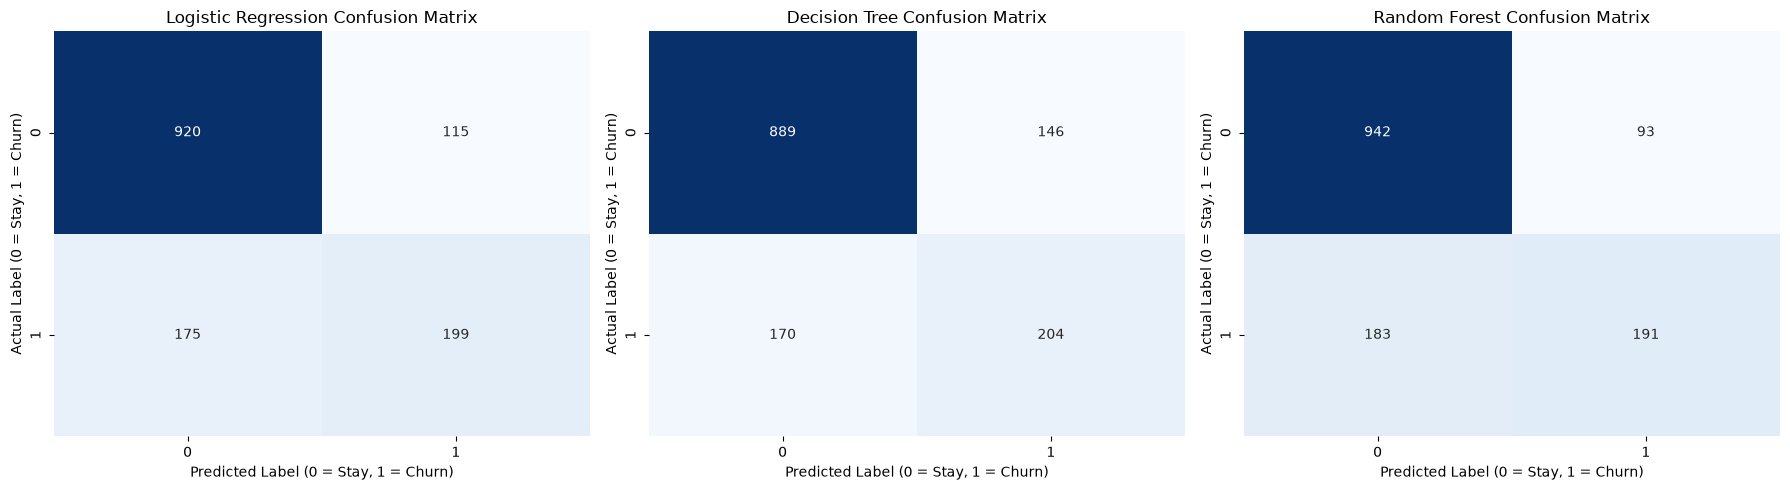

In [40]:
# Evaluating improved models

improved_models = {
    "Logistic Regression": best_log,
    "Decision Tree": best_tree,
    "Random Forest": best_rf
}

#Confusion matrices for the best models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, improved_models.items()):
    y_pred = model.predict(x_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel('Predicted Label (0 = Stay, 1 = Churn)')
    ax.set_ylabel('Actual Label (0 = Stay, 1 = Churn)')

plt.tight_layout()
plt.show()

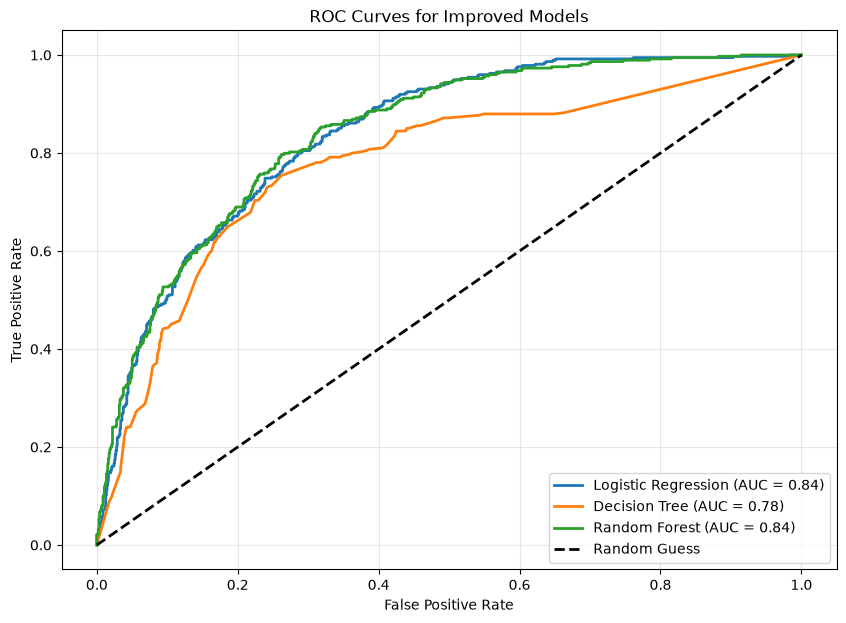

In [42]:
# ROC curves for improved models

plt.figure(figsize=(10, 7))

for name, model in improved_models.items():
    y_probs = model.predict_proba(x_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Improved Models')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


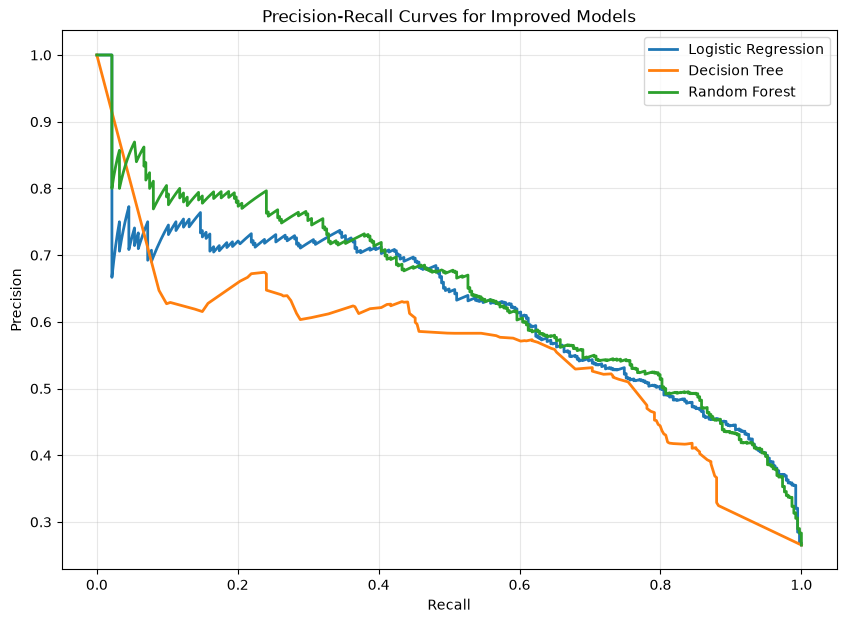

In [43]:
# Precision-Recall curves for improved models

plt.figure(figsize=(10, 7))

for name, model in improved_models.items():
    y_probs = model.predict_proba(x_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    plt.plot(recall, precision, lw=2, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Improved Models')
plt.legend()
plt.grid(alpha=0.3)
plt.show()